In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os

# for the colormap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# List of parameters that vary in our simulation

In [33]:
nqubits_list = [5, 7] #[5, 7, 9, 10]
gamma_list = np.arange(0, 0.4, 0.02)
runs = 10

# Compute error bar

In [34]:
def mean_error(entropy):
  K = len(entropy)
  if K < 2:
    return entropy[0], 0  # Impossible de calculer une erreur avec un seul point

  e_mean = np.mean(entropy, axis=0)
  e_std = np.std(entropy, axis=0)

  return e_mean,  e_std / np.sqrt(K)

# Retrieval of simulation data

In [35]:
def csv_to_df(run, nqubits, gamma) :
  file_name = f"results_N_{nqubits}-gamma_{str(gamma).replace('.', '_')}.csv"
  path= f"/content/drive/MyDrive/resultat_simu_osaka/random_circuit_noisy/run_{run}/N_{nqubits}/"+file_name
  return pd.read_csv(path)

In [36]:
df_dict = {}
for nqubits in nqubits_list :
  print(f"nqubits : {nqubits}")
  for gamma in gamma_list :
    print(f"- gamma : {gamma}")
    renyi_entropy, operator_entanglement = [], []
    for run in range(1, runs+1) :
      if run == 3:
        continue
      df = csv_to_df(run, nqubits, gamma)

      renyi_entropy.append(df["Renyi_entropy"])
      operator_entanglement.append(df["Operator_Entanglement"])

    re_mean, re_error = mean_error(renyi_entropy)
    oe_mean, oe_error = mean_error(operator_entanglement)

    df_dict[(nqubits, gamma)] = pd.DataFrame({"Layer" : df["Layer"],
                                  "Renyi_entropy" : re_mean,
                                  "Renyi_entropy_error" : re_error,
                                  "Operator_Entanglement" : oe_mean,
                                  "Operator_Entanglement_error" : oe_error})

nqubits : 5
- gamma : 0.0
- gamma : 0.02
- gamma : 0.04
- gamma : 0.06
- gamma : 0.08
- gamma : 0.1
- gamma : 0.12
- gamma : 0.14
- gamma : 0.16
- gamma : 0.18
- gamma : 0.2
- gamma : 0.22
- gamma : 0.24
- gamma : 0.26
- gamma : 0.28
- gamma : 0.3
- gamma : 0.32
- gamma : 0.34
- gamma : 0.36
- gamma : 0.38
nqubits : 7
- gamma : 0.0
- gamma : 0.02
- gamma : 0.04
- gamma : 0.06
- gamma : 0.08
- gamma : 0.1
- gamma : 0.12
- gamma : 0.14
- gamma : 0.16
- gamma : 0.18
- gamma : 0.2
- gamma : 0.22
- gamma : 0.24
- gamma : 0.26
- gamma : 0.28
- gamma : 0.3
- gamma : 0.32
- gamma : 0.34
- gamma : 0.36
- gamma : 0.38


# Thermalisation parameter

It is at this level that we consider our system to be stable

In [37]:
thermalisation_layer = 30

# Plot entropies vs layer

In [47]:
# Define the directory to save figures
save_dir = 'figures'
os.makedirs(save_dir, exist_ok=True) # Create the directory if it doesn't exist

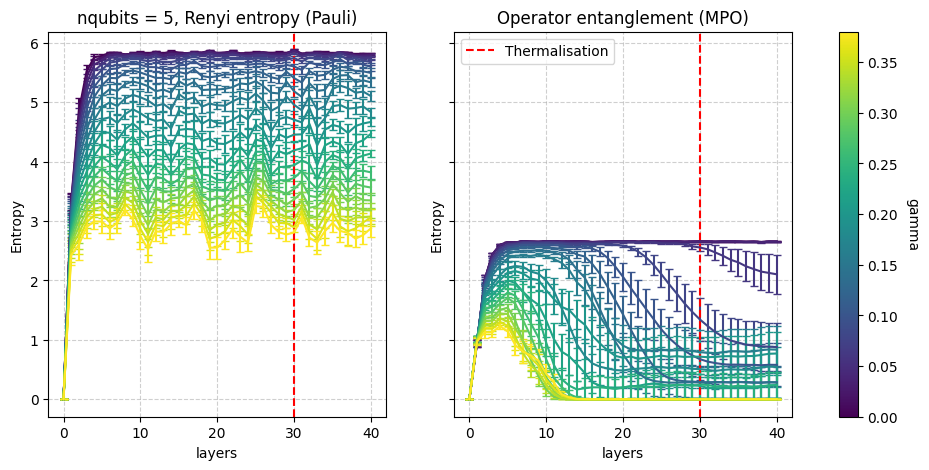

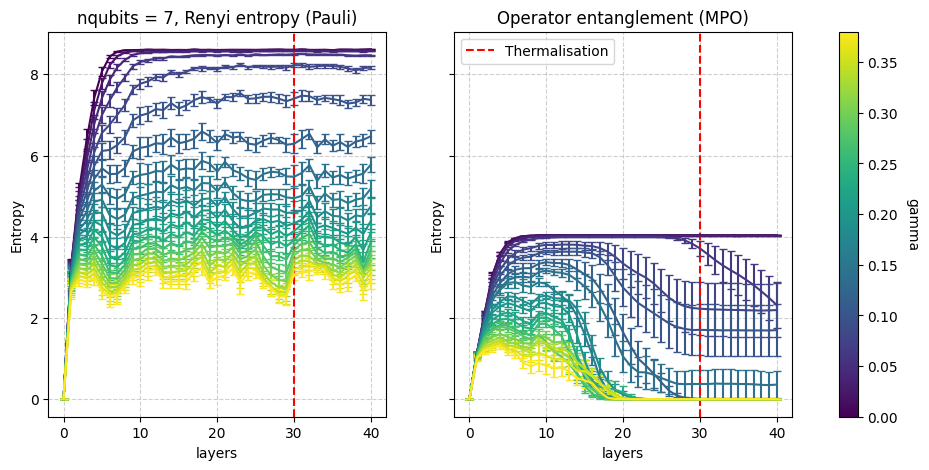

In [50]:
cmap = plt.get_cmap('viridis') # inferno, rainbow, RdBu, Blues
norm = Normalize(vmin=gamma_list.min(), vmax=gamma_list.max())

for nqubits in nqubits_list:
  fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

  for gamma in gamma_list:
    df = df_dict[(nqubits, gamma)]
    axes[0].errorbar(df["Layer"], df["Renyi_entropy"], yerr=df["Renyi_entropy_error"], capsize=3, color=cmap(norm(gamma)))
    axes[1].errorbar(df["Layer"], df["Operator_Entanglement"], yerr=df["Operator_Entanglement_error"], capsize=3, color=cmap(norm(gamma)))

  for i in range(2):
    axes[i].set_xlabel("layers")
    axes[i].set_ylabel("Entropy")
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].axvline(x=thermalisation_layer, color='red',linestyle='--', label="Thermalisation")

  axes[0].set_title(f"nqubits = {nqubits}, Renyi entropy (Pauli)")
  axes[1].set_title("Operator entanglement (MPO)")

  sm = ScalarMappable(cmap=cmap, norm=norm)
  sm.set_array(gamma_list)
  cbar = fig.colorbar(sm, ax=axes)
  cbar.set_label("gamma", loc='center', rotation=270, labelpad=15)

  plt.legend()
  plt.show()

  # Save the figure
  fig_name = f"entropy_vs_layer_nqubits_{nqubits}.png"
  fig_path = os.path.join(save_dir, fig_name)
  fig.savefig(fig_path, dpi=150)
  plt.close(fig)

# Plot average entropies vs number of qubits, Complexity

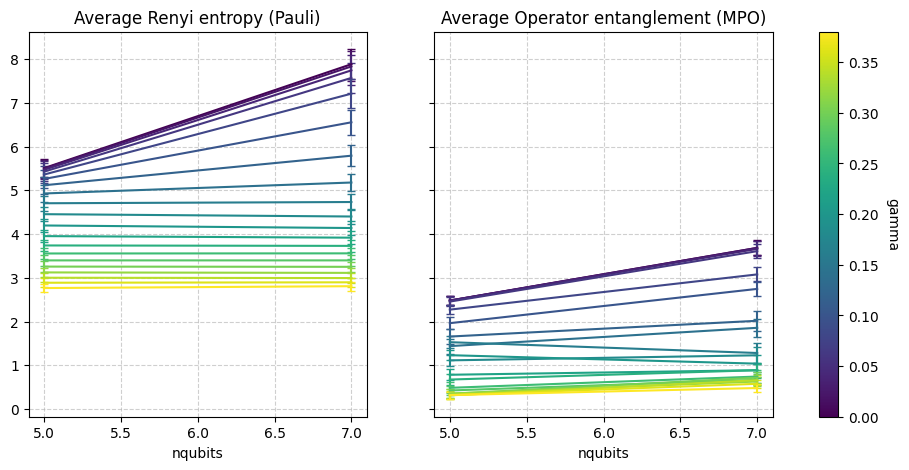

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=gamma_list.min(), vmax=gamma_list.max())

for gamma in gamma_list:
  renyi_entropy_average, operator_entanglement_average = [], []
  renyi_entropy_error, operator_entanglement_error = [], []

  for nqubits in nqubits_list:
    df = df_dict[(nqubits, gamma)]

    re_mean, re_error = mean_error(df["Renyi_entropy"][:thermalisation_layer])
    oe_mean, oe_error = mean_error(df["Operator_Entanglement"][:thermalisation_layer])

    renyi_entropy_average.append(re_mean)
    operator_entanglement_average.append(oe_mean)
    renyi_entropy_error.append(re_error)
    operator_entanglement_error.append(oe_error)

  axes[0].errorbar(nqubits_list, renyi_entropy_average, yerr=renyi_entropy_error, capsize=3, color=cmap(norm(gamma)))
  axes[1].errorbar(nqubits_list, operator_entanglement_average, yerr=operator_entanglement_error, capsize=3, color=cmap(norm(gamma)))

axes[0].set_title("Average Renyi entropy (Pauli)")
axes[1].set_title("Average Operator entanglement (MPO)")

for i in range(2):
  axes[i].set_xlabel("nqubits")
  axes[i].grid(True, linestyle='--', alpha=0.6)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(gamma_list)
cbar = fig.colorbar(sm, ax=axes)
cbar.set_label("gamma", loc='center', rotation=270, labelpad=15)

plt.show()

# Save the figure
fig_name = "average_entropy_vs_nqubits.png"
fig_path = os.path.join(save_dir, fig_name)
fig.savefig(fig_path, dpi=150)
plt.close(fig) # Close the figure to free memory